In [1]:
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
from lics_unwrap import *

setting pyproj data directory


In [ ]:
def convert_wrapper(ifgd, is_sbovl=False):
    # if np.mod(ifgd, 10) == 0:
    print(f"  Processing {ifgd}...", flush=True)

    # Initialize suffix and cycle based on type
    if is_sbovl:
        suffix = ['.geo.sbovldiff.adf.mm.tif', '.geo.cc.tif', '.sbovldiff.adf.mm', '.cc']
        cycle = 75

        # Check for sbovldiff files first
        unw_tiffile = os.path.join(geocdir, ifgd, ifgd + suffix[0])
        cc_tiffile = os.path.join(geocdir, ifgd, ifgd + suffix[1])

        if not os.path.exists(unw_tiffile) or not os.path.exists(cc_tiffile):
            print(f'  No {ifgd + suffix[0]} or {ifgd + suffix[1]} found. Checking bovldiff files...', flush=True)

            # Fall back to bovldiff if sbovldiff not found
            unw_tiffile = os.path.join(geocdir, ifgd, ifgd + '.geo.bovldiff.adf.mm.tif')
            cc_tiffile = os.path.join(geocdir, ifgd, ifgd + '.geo.cc.tif')

            if not os.path.exists(unw_tiffile) or not os.path.exists(cc_tiffile):
                print(f'  No {ifgd + ".geo.bovldiff.adf.mm.tif"} or {ifgd + ".geo.cc.tif"} found. Skip.', flush=True)
                return 1

    else:
        # Default case for non-sbovl processing
        suffix = ['.geo.unw.tif', '.geo.cc.tif', '.unw', '.cc']
        cycle = 3
        unw_tiffile = os.path.join(geocdir, ifgd, ifgd + suffix[0])
        cc_tiffile = os.path.join(geocdir, ifgd, ifgd + suffix[1])

        if not os.path.exists(unw_tiffile) or not os.path.exists(cc_tiffile):
            print(f'  No {ifgd + suffix[0]} or {ifgd + suffix[1]} found. Skip.', flush=True)
            return 1

    # Output directories and files
    ifgdir1 = os.path.join(outdir, ifgd)
    if not os.path.exists(ifgdir1):
        os.mkdir(ifgdir1)
    unwfile = os.path.join(ifgdir1, ifgd + suffix[2])
    ccfile = os.path.join(ifgdir1, ifgd + suffix[3])

    # Read data from GeoTIFF
    try:
        unw = gdal.Open(unw_tiffile).ReadAsArray()
        unw[unw == 0] = np.nan
    except:
        print(f'  {unw_tiffile} cannot open. Skip.', flush=True)
        shutil.rmtree(ifgdir1)
        return 1

    try:
        cc = gdal.Open(cc_tiffile).ReadAsArray()
        if cc.dtype == np.float32:
            cc = cc * 255  # Convert 0-1 to 0-255 for uint8
    except:
        print(f'  {cc_tiffile} cannot open. Skip.', flush=True)
        shutil.rmtree(ifgdir1)
        return 1

    # Dimension check
    if width:
        if (cc.shape != (length, width)) or (unw.shape != (length, width)):
            print(f'pair {ifgd} has different dimensions. Skipping.', flush=True)
            return 1

    # Multilook processing if needed
    if nlook != 1:
        cc = cc.astype(np.float32)
        cc[cc == 0] = np.nan  # Treat zero coherence as missing data (NaN)

        # Apply weighted multilook to `unw` using coherence as weights
        unw = tools_lib.multilook_weighted(unw, cc, nlook, nlook, n_valid_thre)

        # Apply weighted multilook to `cc`, using itself as the coherence weight
        cc = tools_lib.multilook_weighted(cc, cc, nlook, nlook, n_valid_thre)

    # Save float outputs
    unw.tofile(unwfile)
    cc = np.nan_to_num(cc, nan=0)
    cc = cc.astype(np.uint8)  # Convert NaNs to 0, auto-floor to max 255
    cc.tofile(ccfile)

    # Generate png images
    if plot_cc:
        ccpngfile = os.path.join(ifgdir1, ifgd + suffix[3] + '.png')
        cc = cc.astype(np.float32)
        cc[np.where(np.isnan(unw))] = np.nan
        plot_lib.make_im_png(cc / 255, ccpngfile, cmap_cc, ifgd + suffix[3], vmin=0.03, vmax=1, cbar=True, logscale=True)

    unwpngfile = os.path.join(ifgdir1, ifgd + suffix[2] + '.png')
    plot_lib.make_im_png(np.angle(np.exp(1j * unw / cycle) * cycle), unwpngfile, cmap_wrap, ifgd + suffix[2], vmin=-np.pi, vmax=np.pi, cbar=False)

    return 0

In [174]:
bovl_data='/work/scratch-pw2/licsar/mnergiz/SBOI_trial/021D_05266_252525/GEOC/20200103_20200115/20200103_20200115.geo.sbovldiff.adf.mm.tif'
cc_data='/work/scratch-pw2/licsar/mnergiz/SBOI_trial/021D_05266_252525/GEOC/20200103_20200115/20200103_20200115.geo.cc.tif'

In [175]:
unw = gdal.Open(bovl_data).ReadAsArray()
unw[unw == 0] = np.nan

In [176]:
cc = gdal.Open(cc_data).ReadAsArray()
if cc.dtype == np.float32:
    cc = cc * 255  # Convert 0-1 to 0-255 for uint8
    cc[cc == 0] = np.nan  # Treat zero coherence as missing data (NaN)

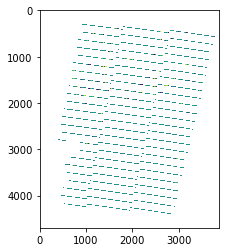

In [4]:
plt.imshow(unw, interpolation='nearest')

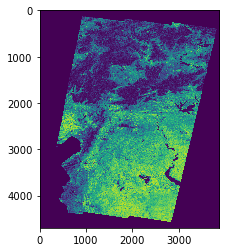

In [7]:
plt.imshow(cc, interpolation='nearest')

In [ ]:
def multilook_weighted(array, coherence, nlook_r, nlook_c, n_valid_thre=0.5, coh_thre=0.75):
    """
    Apply multilooking to the array, with weights based on coherence.
    Low-coherence pixels are ignored if they fall below the coherence threshold (coh_thre).
    
    Parameters:
    - array (ndarray): Input data array with `nan` for nodata.
    - coherence (ndarray): Coherence array with the same shape as `array`.
    - nlook_r (int): Number of rows to average in multilooking.
    - nlook_c (int): Number of columns to average in multilooking.
    - n_valid_thre (float): Minimum valid data fraction to keep pixel (default: 0.5).
    - coh_thre (float): Minimum coherence threshold to include pixel in multilooking.

    Returns:
    - array_ml (ndarray): Multilooked array.
    """
    length, width = array.shape
    length_ml = int(np.floor(length / nlook_r))
    width_ml = int(np.floor(width / nlook_c))

    # Reshape for block processing
    array_reshape = array[:length_ml * nlook_r, :width_ml * nlook_c].reshape(length_ml, nlook_r, width_ml, nlook_c)
    coherence_reshape = coherence[:length_ml * nlook_r, :width_ml * nlook_c].reshape(length_ml, nlook_r, width_ml, nlook_c)

    # Mask low-coherence pixels
    valid_mask = coherence_reshape >= coh_thre
    array_reshape[~valid_mask] = np.nan

    # Calculate weighted mean based on coherence
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        weighted_array = array_reshape * coherence_reshape
        sum_weights = np.nansum(coherence_reshape, axis=(1, 3))
        array_ml = np.nansum(weighted_array, axis=(1, 3)) / sum_weights

    # Apply validity threshold
    n_valid = np.sum(~np.isnan(array_reshape), axis=(1, 3))
    bool_invalid = n_valid < n_valid_thre * nlook_r * nlook_c
    array_ml[bool_invalid] = np.nan

    return array_ml

In [5]:
# Apply weighted multilook to `unw` using coherence as weights
unw_a = tools_lib.multilook_weighted(unw, cc, nlook, nlook, n_valid_thre)

(4694, 3867)

In [177]:
nlook_r=15
nlook_c=15
coh_thre=0.7
array=unw
coherence=cc/255
n_valid_thre=0.25
coh_thre=0.75

length, width = unw.shape
length_ml = int(np.floor(length / nlook_r))
width_ml = int(np.floor(width / nlook_c))

# Reshape for block processing
array_reshape = array[:length_ml * nlook_r, :width_ml * nlook_c].reshape(length_ml, nlook_r, width_ml, nlook_c)
coherence_reshape = coherence[:length_ml * nlook_r, :width_ml * nlook_c].reshape(length_ml, nlook_r, width_ml, nlook_c)


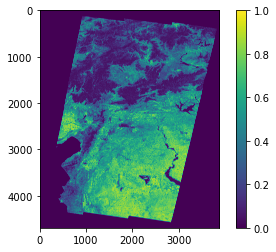

In [178]:
plt.imshow(coherence)
plt.colorbar()

In [179]:
# Mask low-coherence pixels
valid_mask = coherence_reshape >= 0.4
array_reshape[~valid_mask] = np.nan

In [197]:
# Calculate weighted mean based on coherence
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    weighted_array = array_reshape * coherence_reshape
    sum_weights = np.nansum(coherence_reshape, axis=(1, 3))
    array_ml = np.nansum(weighted_array, axis=(1, 3)) / sum_weights
    array_ml[sum_weights == 0] = np.nan

# Apply validity threshold
n_valid = np.sum(~np.isnan(array_reshape), axis=(1, 3))
bool_invalid = n_valid < 0.2 * nlook_r * nlook_c
array_ml[bool_invalid] = np.nan

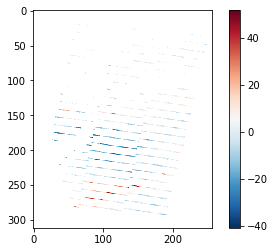

In [198]:
plt.imshow(array_ml, interpolation='nearest',cmap='RdBu_r')
plt.colorbar()

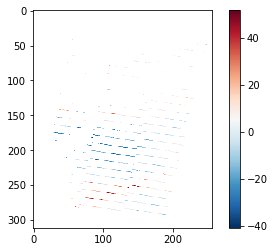

In [196]:
plt.imshow(array_ml, interpolation='nearest',cmap='RdBu_r')
plt.colorbar()

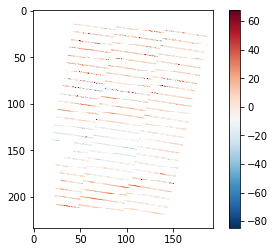

In [89]:
plt.imshow(array_ml, interpolation='nearest',cmap='RdBu_r')
plt.colorbar()

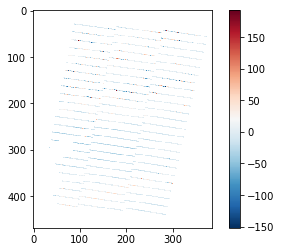

In [77]:
plt.imshow(array_ml, interpolation='nearest',cmap='RdBu_r')
plt.colorbar()

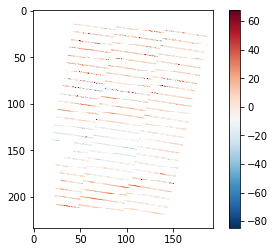

In [81]:
plt.imshow(array_ml, interpolation='nearest',cmap='RdBu_r')
plt.colorbar()

In [72]:
np.shape(array_ml)

(93, 77)

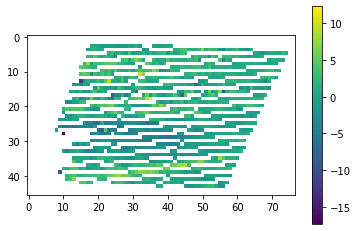

In [63]:
plt.imshow(array_ml, interpolation='nearest')
plt.colorbar()

In [24]:
a=(np.nansum(weighted_array, axis=(1, 3))) 

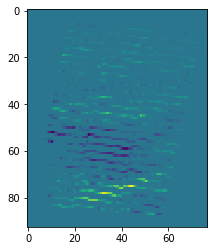

In [25]:
plt.imshow(a, interpolation='nearest')

In [91]:
bovl_xr=load_tif2xr(bovl_data)
coh_xr=load_tif2xr(cc_data)

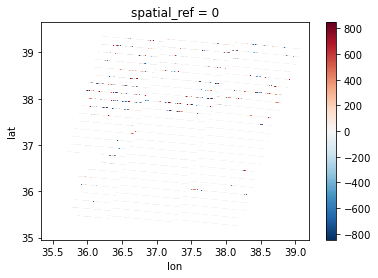

In [85]:
bovl_xr.plot()

In [90]:
bovl_xr

<xarray.DataArray (lat: 4694, lon: 3867)>
[18151698 values with dtype=float32]
Coordinates:
  * lon          (lon) float64 35.33 35.33 35.33 35.33 ... 39.19 39.19 39.2
  * lat          (lat) float64 39.65 39.65 39.64 39.64 ... 34.96 34.95 34.95
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [93]:
import numpy as np
import xarray as xr

def multilook_weighted_xarray(data, coherence, look_km=1.5):
    """
    Multilook (downsample) an xarray.DataArray with weighted averaging using coherence.

    Parameters:
    - data (xr.DataArray): Input data (e.g., unwrapped phase or velocity).
    - coherence (xr.DataArray): Same shape as `data`, coherence values (0–1).
    - look_km (float): Approximate multilooking window size in kilometers (default: 1.5 km).

    Returns:
    - xr.DataArray: Downsampled multilooked data.
    """

    # Estimate grid spacing in degrees
    lat_spacing = float(np.abs(data.lat[1] - data.lat[0]))
    lon_spacing = float(np.abs(data.lon[1] - data.lon[0]))

    # Convert 1.5 km to degrees
    lat_deg = look_km / 111  # ~0.0135 deg
    mid_lat = float(data.lat.mean())
    lon_deg = look_km / (111 * np.cos(np.deg2rad(mid_lat)))  # lon varies with latitude

    # Calculate number of pixels for coarsening
    nlook_r = max(1, int(round(lat_deg / lat_spacing)))
    nlook_c = max(1, int(round(lon_deg / lon_spacing)))

    # Avoid mismatch
    if data.shape != coherence.shape:
        raise ValueError("Input data and coherence must have the same shape")

    # Prepare masked data and weights
    masked_data = data.where(coherence >= 0.1)  # exclude low-coherence values
    weighted = masked_data * coherence

    # Coarsen using sum and count of valid weights
    weight_sum = coherence.coarsen(lat=nlook_r, lon=nlook_c, boundary='trim').sum()
    weighted_sum = weighted.coarsen(lat=nlook_r, lon=nlook_c, boundary='trim').sum()
    count_valid = coherence.coarsen(lat=nlook_r, lon=nlook_c, boundary='trim').count()

    # Weighted average, apply nan where few valid points
    multilooked = weighted_sum / weight_sum
    multilooked = multilooked.where(count_valid >= 0.5 * nlook_r * nlook_c)

    return multilooked


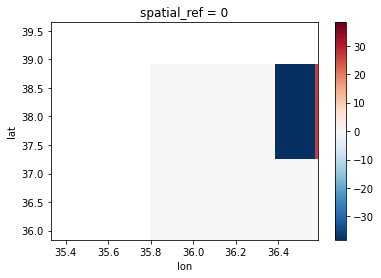

In [94]:
bovl_ml = multilook_weighted_xarray(bovl_xr, coh_xr, look_km=1.5)
bovl_ml.plot()


In [133]:
np.shape(bovl_xr.data)

(4694, 3867)

In [132]:
nlook_r

15

In [117]:
data=bovl_xr
coherence=coh_xr
coherence.data=coherence.data/255
look_km=1.5

In [134]:
lat_spacing = np.abs(data.lat[1] - data.lat[0])  # degrees
lon_spacing = np.abs(data.lon[1] - data.lon[0])  # degrees


In [135]:
lat_spacing

<xarray.DataArray 'lat' ()>
array(0.0009999999999976694)
Coordinates:
    spatial_ref  int64 0

In [136]:
import numpy as np
import xarray as xr

# --- Estimate grid spacing in degrees
lat_spacing = float(np.abs(data.lat[1] - data.lat[0]))
lon_spacing = float(np.abs(data.lon[1] - data.lon[0]))

# --- Define target spacing in kilometers
look_km = 1.5

# --- Convert km to degrees
deg_per_km_lat = 1 / 111  # approx for latitude
mid_lat = float(data.lat.mean())
deg_per_km_lon = 1 / (111 * np.cos(np.deg2rad(mid_lat)))  # varies with latitude

lat_deg = look_km * deg_per_km_lat
lon_deg = look_km * deg_per_km_lon

# --- Calculate number of pixels per look direction
nlook_r = max(1, int(round(lat_deg / lat_spacing)))
nlook_c = max(1, int(round(lon_deg / lon_spacing)))


Using nlook_r=14, nlook_c=17 for ~1.5 km multilooking.


In [141]:
nlook_c

17

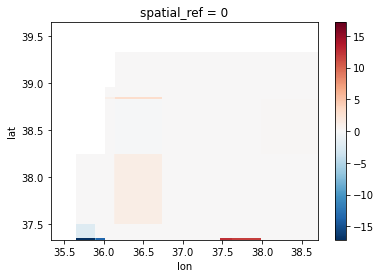

In [128]:
multilooked.plot()

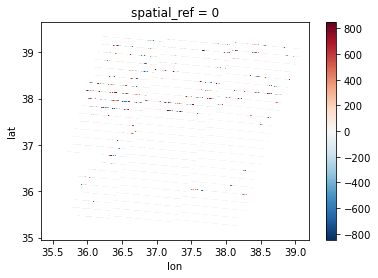

In [114]:
masked_data.plot()

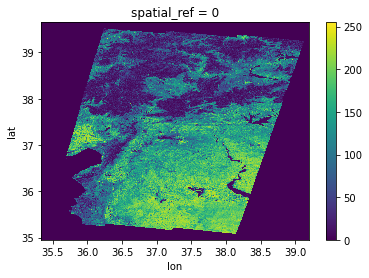

In [116]:
coherence.plot()